In [20]:
!pip3 install spicelib

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


Simulating...

✅ ¡Simulación terminada!
📄 RAW: results_ac/preamp_ac_sweep_2d_1.raw
📄 LOG: results_ac/preamp_ac_sweep_2d_1.log

--- 🔍 Resumen del Archivo LOG ---
  -> Warning: Multiple definitions of model "2scr375p" Type: BJT
  -> Warning: Multiple definitions of model "bc857b" Type: BJT
  -> Warning: Multiple definitions of model "bc847c" Type: BJT
  -> Warning: Multiple definitions of model "bc847b" Type: BJT
  -> Total elapsed time: 0.462 seconds.
----------------------------------

📊 Extrayendo datos y generando gráfico...


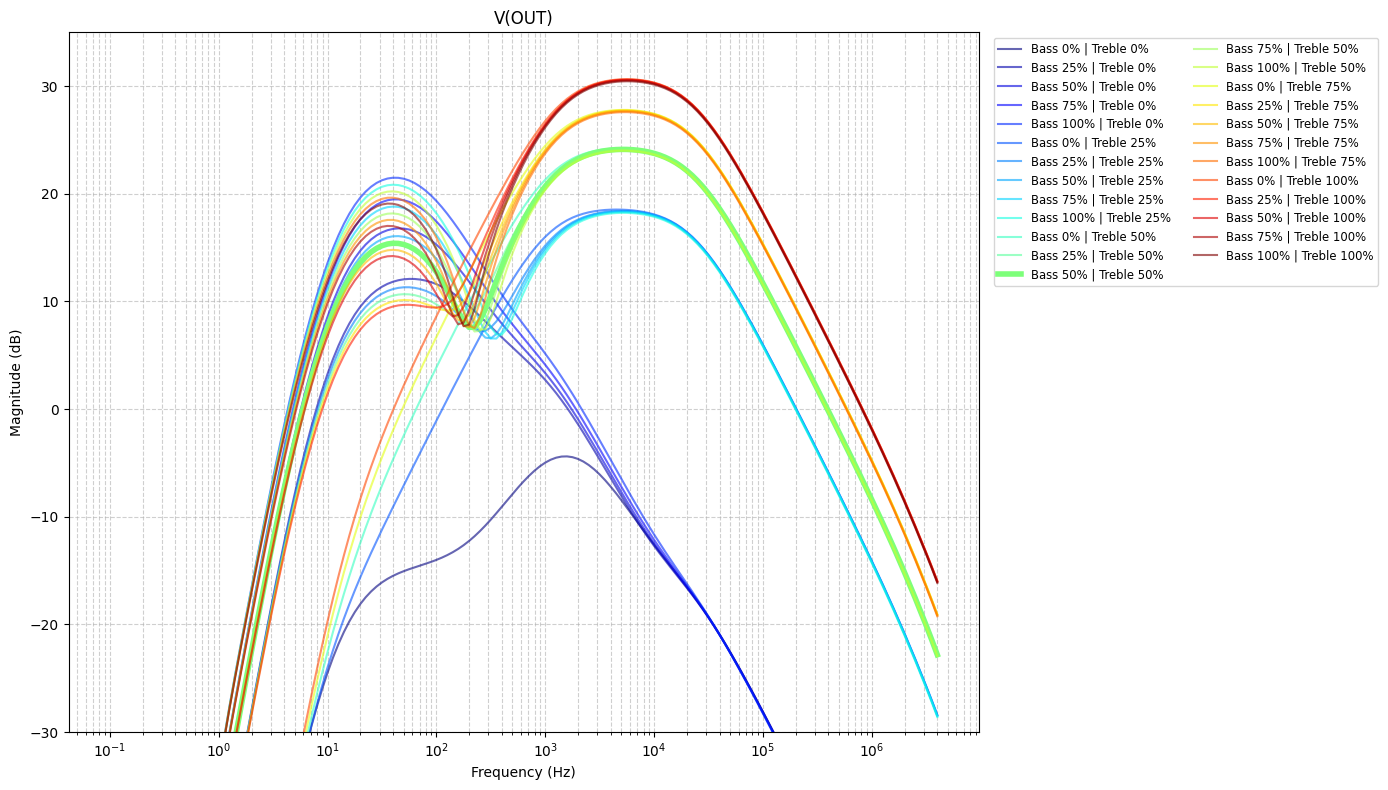

In [78]:
from spicelib import SpiceEditor, SimRunner, RawRead
from spicelib.simulators.ltspice_simulator import LTspice
import matplotlib.pyplot as plt
import numpy as np
import shutil
import os

results_dir = './results_ac'
if os.path.exists(results_dir):
    shutil.rmtree(results_dir) # Borra la carpeta y todo su contenido
os.makedirs(results_dir)       # La vuelve a crear vacía y limpia

# Definir la ruta del ejecutable de LTspice en macOS
class MacLTspice(LTspice):
    spice_exe = ['/Applications/LTspice.app/Contents/MacOS/LTspice']

#netlist = SpiceEditor("../schematics/redcircuits_design/red_circuits_design.net")
netlist = SpiceEditor("../schematics/iteration1/redesign_15v.net")
netlist.remove_component('V1')

# spicelib seems to be buggy! empty lines are problematic
netlist.netlist = [x for x in netlist.netlist if x.strip()]


netlist.add_instruction("V_AC IN 0 AC 1")
netlist.add_instruction(".ac dec 20 0.1 4000k")

# I need to add this from time to time
netlist.netlist = [x for x in netlist.netlist if x.strip()] 

netlist.add_instruction(".step param bass list 0 0.25 0.5 0.75 1")
netlist.add_instruction(".step param treble list 0 0.25 0.5 0.75 1")

netlist.set_parameters(vol=1.0, brightness=0.0, drive=0.0)  # no need to set in_amplitude or in_freq, we are in .ac mode


netlist.save_netlist("preamp_ac_sweep_2d.net")
print("Simulating...")

runner = SimRunner(simulator=MacLTspice, output_folder='./results_ac')
runner.run("preamp_ac_sweep_2d.net")

# El bucle 'for' actuará como bloqueante natural hasta que LTspice termine
for raw_path, log_path in runner:
    print(f"\n✅ ¡Simulación terminada!")
    print(f"📄 RAW: {raw_path}")
    print(f"📄 LOG: {log_path}")

    # --- EJEMPLO: RECUPERAR INFORMACIÓN DEL LOG ---
    # Leemos el archivo .log como un archivo de texto normal para buscar métricas o errores
    if os.path.exists(log_path):
        print("\n--- 🔍 Resumen del Archivo LOG ---")
        with open(log_path, 'r', encoding='utf-16-le', errors='ignore') as log_file:
            for linea in log_file:
                # Buscamos palabras clave de interés en cada línea
                if "Warning" in linea or "Fatal Error" in linea or "Total elapsed time" in linea:
                    print(f"  -> {linea.strip()}")
        print("----------------------------------\n")

    # --- LECTURA DE DATOS RAW Y PLOTEO ---
    if not os.path.exists(raw_path):
        print(f"❌ Error: El archivo {raw_path} no se generó correctamente.")
        continue

    print("📊 Extrayendo datos y generando gráfico...")
    raw = RawRead(raw_path)
    pasos_indices = raw.get_steps() 
    
    colores = plt.cm.jet(np.linspace(0, 1, len(pasos_indices)))
    plt.figure(figsize=(14, 8))
    
    for i in pasos_indices:
        # EXTRACCIÓN MANUAL DE FRECUENCIA PARA ESQUIVAR EL BUG DE get_axis()
        try:
            freq_complex = raw.get_trace('frequency').get_wave(i)
        except KeyError:
            freq_complex = raw.get_trace('freq').get_wave(i)
            
        freq = np.real(freq_complex)
        
        # Petición del nodo de salida
        try:
            v_out_complex = raw.get_trace('V(OUT)').get_wave(i)
        except KeyError:
            v_out_complex = raw.get_trace('V(out)').get_wave(i)
            
        # Calcular Magnitud en dB
        v_out_mag = np.abs(v_out_complex)
        v_out_db = 20 * np.log10(v_out_mag + 1e-12) 
        
        # Leer parámetros para la leyenda
        step_info = raw.steps[i]
        b_val = step_info.get('bass', 0)
        t_val = step_info.get('treble', 0)
        
        b_pct = int(b_val * 100)
        t_pct = int(t_val * 100)
        
        # Estilos: destacar la curva central (50/50)
        grosor = 4 if (b_pct == 50 and t_pct == 50) else 1.5
        alpha_val = 1.0 if (b_pct == 50 and t_pct == 50) else 0.6
        
        plt.plot(freq, v_out_db, label=f'Bass {b_pct}% | Treble {t_pct}%', 
                 color=colores[i], linewidth=grosor, alpha=alpha_val)

    # Configuración visual del gráfico principal
    plt.title("V(OUT)")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.xscale('log') 
    plt.ylim([-30, 35])
    plt.grid(True, which='both', linestyle='--', alpha=0.6)
    
    # Leyenda fuera del área de ploteo
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='small', ncol=2)
    plt.tight_layout()
    plt.show()

In [3]:
!ls ../schematics/redcircuits_design/

red_circuits_design.asc


Simulating Noise Performance...

✅ Simulation Finished!
📊 Extracting noise data...


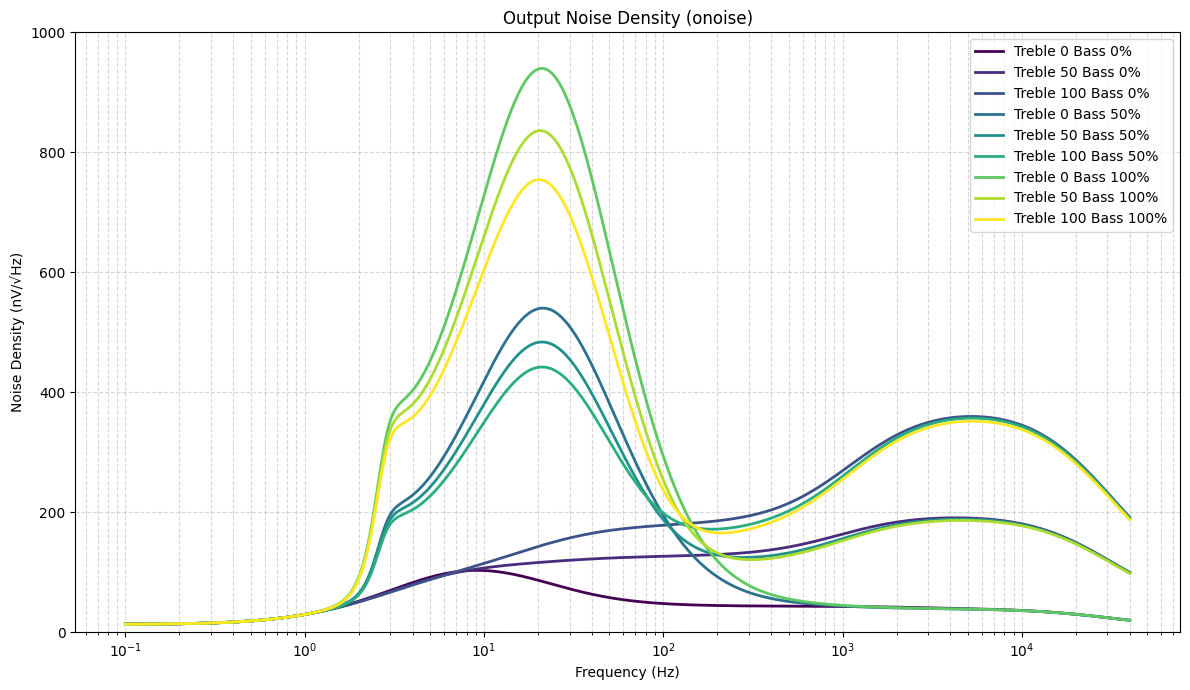

In [80]:
from spicelib import SpiceEditor, SimRunner, RawRead
from spicelib.simulators.ltspice_simulator import LTspice
import matplotlib.pyplot as plt
import numpy as np
import shutil
import os

results_dir = './results_noise'
if os.path.exists(results_dir):
    shutil.rmtree(results_dir) 
os.makedirs(results_dir)

class MacLTspice(LTspice):
    spice_exe = ['/Applications/LTspice.app/Contents/MacOS/LTspice']

# Path to your netlist
netlist = SpiceEditor("../schematics/iteration1/redesign_15v.net")
#netlist = SpiceEditor("../schematics/redcircuits_design/red_circuits_design.net")
netlist.remove_component('V1')

# Clean up empty lines
netlist.netlist = [x for x in netlist.netlist if x.strip()]

# NOISE INSTRUCTION: .noise V(OUTPUT_NODE) SOURCE_NAME TYPE POINTS START STOP
# We analyze output noise relative to a 1V AC input at IN
netlist.add_instruction("V_AC IN 0 AC 1") 
netlist.add_instruction(".noise V(OUT) V_AC dec 100 0.1 40k")

# Optional: You can still step parameters to see how Bass/Treble affect noise
netlist.add_instruction(".step param treble list 0 0.5 1")
netlist.add_instruction(".step param bass list 0 0.5 1")

# Set static parameters
netlist.set_parameters(vol=1.0, drive=0.5, bass=0.5)

netlist.save_netlist("preamp_noise_analysis.net")
print("Simulating Noise Performance...")

runner = SimRunner(simulator=MacLTspice, output_folder='./results_noise')
runner.run("preamp_noise_analysis.net")

for raw_path, log_path in runner:
    print(f"\n✅ Simulation Finished!")
    
    if not os.path.exists(raw_path):
        print(f"❌ Error: {raw_path} not found.")
        continue

    print("📊 Extracting noise data...")
    raw = RawRead(raw_path)
    pasos_indices = raw.get_steps() 
    
    plt.figure(figsize=(12, 7))
    colores = plt.cm.viridis(np.linspace(0, 1, len(pasos_indices)))

    for i in pasos_indices:
            # 1. Get Frequency axis (remains the same)
            try:
                freq_complex = raw.get_trace('frequency').get_wave(i)
            except KeyError:
                freq_complex = raw.get_trace('freq').get_wave(i)
            freq = np.real(freq_complex)
            
            # 2. Get Noise Trace - Updated to look for V(onoise)
            try:
                # Try the formal LTspice name first
                v_noise = raw.get_trace('V(onoise)').get_wave(i)
            except (KeyError, IndexError):
                try:
                    # Fallback to the short name
                    v_noise = raw.get_trace('onoise').get_wave(i)
                except (KeyError, IndexError):
                    print(f"❌ Error: Could not find noise trace in step {i}")
                    continue
                
            # Noise is returned as a complex number (magnitude/phase), 
            # though phase is usually 0 for noise density.
            v_noise_density = np.abs(v_noise)
            
            # Convert to nV/sqrt(Hz) for a readable scale (e.g., 20nV instead of 0.00000002)
            v_noise_nv = v_noise_density * 1e9 
            
            # 3. Handle step info and plotting
            step_info = raw.steps[i]
            t_val = step_info.get('treble', 0.5)
            t_pct = int(t_val * 100)
            b_val = step_info.get('bass', 0.5)
            b_pct = int(b_val * 100)
            plt.plot(freq, v_noise_nv, label=f'Treble {t_pct} Bass {b_pct}%', 
                     color=colores[i], linewidth=2)

    # UI Configuration
    plt.title("Output Noise Density (onoise)")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Noise Density (nV/√Hz)")
    plt.xscale('log') 
    plt.ylim([0, 1000])
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [48]:
import os
import csv
import glob
import numpy as np
from spicelib import SpiceEditor, SimRunner, RawRead
from spicelib.simulators.ltspice_simulator import LTspice

# Define your custom Mac LTspice runner
class MacLTspice(LTspice):
    spice_exe = ['/Applications/LTspice.app/Contents/MacOS/LTspice']

# Directories and paths
out_dir = "/Users/emolina/git/electrucio_updates/guitar_preamplifier/schematics/iteration1/audios"
input_wav_path = "/Users/emolina/git/electrucio_updates/guitar_preamplifier/schematics/iteration1/audios/dry_guitar_44100_selection.wav"
netlist_path = "../schematics/iteration1/redesign_15v.net"

# Ensure output directory exists
os.makedirs(out_dir, exist_ok=True)

# Define the parameter steps
vol = 0.4
drive_steps = [0.0, 1.0]
bass_treble_pairs = [(1.0, 0.5), (0.5, 1.0)]

# Initialize runner
runner = SimRunner(simulator=MacLTspice, output_folder=out_dir)
csv_filepath = os.path.join(out_dir, "preamp_analysis.csv")

print(f"Starting sequential simulation. Total runs: {len(drive_steps) * len(bass_treble_pairs)}")

# Open the CSV once using 'with' so we can append to it sequentially
with open(csv_filepath, mode='w', newline='') as csv_file:
    writer = csv.writer(csv_file)
    writer.writerow(["Drive", "Bass", "Treble", "Volume", "Max_Vout_Peak", "WAV_File"])

    for drive in drive_steps:
        for bass, treble in bass_treble_pairs:
            
            # 1. Define filenames
            wav_filename = f"preamp_d{drive}_b{bass}_t{treble}_v{vol}.wav"
            wav_filepath = os.path.join(out_dir, wav_filename)
            
            base_tmp_name = f"preamp_tmp_d{drive}_b{bass}_t{treble}"
            tmp_netlist = f"{base_tmp_name}.net"
            tmp_netlist_path = os.path.join(out_dir, tmp_netlist)
            
            # 2. Setup Netlist
            netlist = SpiceEditor(netlist_path)
            params = {"vol": vol, "drive": drive, "bass": bass, "treble": treble}
            netlist.set_parameters(**params)
            v1_wav_value = f'wavefile="{input_wav_path}" chan=0'
            netlist.set_component_value('V1', v1_wav_value)
            # Add audio export and tell LTspice to only save V(out) to save space
            netlist.add_instruction(f'.wave "{wav_filepath}" 32 48000 V(out)')
            netlist.add_instruction('.save V(out)')
            netlist.add_instruction('.tran 0 20 0 1u')
            netlist.save_netlist(tmp_netlist_path)
            
            print(f"\nRunning: Drive={drive}, Bass={bass}, Treble={treble}...")
            
            # 3. Execute and wait for THIS run to finish
            runner.run(tmp_netlist_path)
            runner.wait_completion()
            
            # 4. Extract Data using glob to find the exact .raw file spicelib generated
            raw_search_pattern = os.path.join(out_dir, f"{base_tmp_name}*.raw")
            found_raw_files = glob.glob(raw_search_pattern)
            
            # Filter out the .op.raw files (Operating Point data)
            main_raw_file = [f for f in found_raw_files if not f.endswith('.op.raw')]
            
            if main_raw_file:
                raw_path = main_raw_file[0]
                try:
                    raw_data = RawRead(raw_path)
                    v_out_trace = raw_data.get_trace("V(out)")
                    v_out_wave = v_out_trace.get_wave(0)
                    max_peak = np.max(np.abs(v_out_wave))
                    
                    # Write to CSV and flush immediately to disk
                    writer.writerow([drive, bass, treble, vol, round(max_peak, 4), wav_filename])
                    csv_file.flush()
                    print(f"Analyzed {wav_filename}: Max Peak = {round(max_peak, 3)} V")
                    
                except Exception as e:
                    print(f"Error reading {raw_path}: {e}")
            else:
                print(f"Warning: Could not find a .raw file for {base_tmp_name}")
            
            # 5. Clean up temporary files for this run
            print("Wiping temporary files...")
            
            # Find ANY file that starts with our temporary base name
            files_to_delete = glob.glob(os.path.join(out_dir, f"{base_tmp_name}*"))
            
            for f in files_to_delete:
                # Extra safety check: never delete the target .wav or .csv files
                if not f.endswith('.wav') and not f.endswith('.csv'):
                    try:
                        os.remove(f)
                    except Exception as e:
                        print(f"Could not delete {f}: {e}")

print(f"\nAll done! Analysis saved to {csv_filepath} and your hard drive is clear of temp files.")

Starting sequential simulation. Total runs: 4

Running: Drive=0.0, Bass=1.0, Treble=0.5...
Analyzed preamp_d0.0_b1.0_t0.5_v0.4.wav: Max Peak = 0.22300000488758087 V
Wiping temporary files...

Running: Drive=0.0, Bass=0.5, Treble=1.0...
Analyzed preamp_d0.0_b0.5_t1.0_v0.4.wav: Max Peak = 0.4169999957084656 V
Wiping temporary files...

Running: Drive=1.0, Bass=1.0, Treble=0.5...
Analyzed preamp_d1.0_b1.0_t0.5_v0.4.wav: Max Peak = 0.4320000112056732 V
Wiping temporary files...

Running: Drive=1.0, Bass=0.5, Treble=1.0...
Analyzed preamp_d1.0_b0.5_t1.0_v0.4.wav: Max Peak = 0.4390000104904175 V
Wiping temporary files...

All done! Analysis saved to /Users/emolina/git/electrucio_updates/guitar_preamplifier/schematics/iteration1/audios/preamp_analysis.csv and your hard drive is clear of temp files.


In [92]:
!pip3 install pyloudnorm soundfile

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [49]:
import os
import glob
import subprocess
import re
import math

# 1. Path Configuration
audio_dir = "/Users/emolina/git/electrucio_updates/guitar_preamplifier/schematics/iteration1/audios/"
ir_path = "/Users/emolina/git/electrucio_updates/guitar_preamplifier/audios/SL_112_Fender_DR_A.wav"

# Search for WAV files
wav_files = glob.glob(os.path.join(audio_dir, "*.wav"))

# Target: 0.9 linear amplitude converted to decibels
target_peak_db = 20 * math.log10(0.9)

print(f"Starting Peak Normalization (0.9) + Fender IR for {len(wav_files)} files...\n")

for wav_path in wav_files:
    base_name = os.path.splitext(wav_path)[0]
    final_mp3_path = f"{base_name}_fender_peak.mp3"
    
    try:
        # --- STEP 1: Detect the maximum peak after applying the IR ---
        # FIX: We combine 'afir' and 'volumedetect' into one complex filter chain
        analysis_filter = "[0:a][1:a]afir,volumedetect"
        
        pass1_cmd = [
            "ffmpeg", "-hide_banner",
            "-i", wav_path,
            "-i", ir_path,
            "-filter_complex", analysis_filter,
            "-f", "null", "-"
        ]
        
        # Run analysis and capture stderr
        result = subprocess.run(pass1_cmd, capture_output=True, text=True, check=True)
        
        # Search for "max_volume" in the logs
        match = re.search(r"max_volume: ([\-\d\.]+) dB", result.stderr)
        if not match:
            print(f"Error: Could not detect peak for {os.path.basename(wav_path)}")
            continue
            
        current_peak_db = float(match.group(1))
        
        # --- STEP 2: Calculate the fixed gain required ---
        needed_gain = target_peak_db - current_peak_db
        
        print(f"File: {os.path.basename(wav_path)}")
        print(f"  > Measured Peak: {current_peak_db} dB | Gain Adjustment: {needed_gain:.2f} dB")

        # --- STEP 3: Apply IR + Fixed Gain + MP3 320k Encoding ---
        # Combining filters here as well for consistency
        processing_filter = f"[0:a][1:a]afir,volume={needed_gain}dB"

        pass2_cmd = [
            "ffmpeg", "-y", "-hide_banner",
            "-i", wav_path,
            "-i", ir_path,
            "-filter_complex", processing_filter,
            "-codec:a", "libmp3lame",
            "-b:a", "320k",
            final_mp3_path
        ]
        
        subprocess.run(pass2_cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=True)
        print(f"  > Exported: {os.path.basename(final_mp3_path)}\n")
        
    except subprocess.CalledProcessError as e:
        print(f"FFmpeg error on {os.path.basename(wav_path)}:")
        # Print the actual FFmpeg error message to help debug
        print(e.stderr)
    except Exception as e:
        print(f"Unexpected error processing {os.path.basename(wav_path)}: {e}")

print("Processing complete!")

Starting Peak Normalization (0.9) + Fender IR for 10 files...

File: preamp_d0.0_b0.5_t1.0_v0.4.wav
  > Measured Peak: -20.5 dB | Gain Adjustment: 19.58 dB
  > Exported: preamp_d0.0_b0.5_t1.0_v0.4_fender_peak.mp3

File: preamp_d0.5_b0.5_t0.5_v0.4.wav
  > Measured Peak: -21.8 dB | Gain Adjustment: 20.88 dB
  > Exported: preamp_d0.5_b0.5_t0.5_v0.4_fender_peak.mp3

File: preamp_d1.0_b0.5_t0.5_v0.4.wav
  > Measured Peak: -19.5 dB | Gain Adjustment: 18.58 dB
  > Exported: preamp_d1.0_b0.5_t0.5_v0.4_fender_peak.mp3

File: preamp_d1.0_b0.5_t1.0_v0.4.wav
  > Measured Peak: -17.5 dB | Gain Adjustment: 16.58 dB
  > Exported: preamp_d1.0_b0.5_t1.0_v0.4_fender_peak.mp3

File: preamp_d0.0_b0.5_t0.5_v0.4.wav
  > Measured Peak: -25.8 dB | Gain Adjustment: 24.88 dB
  > Exported: preamp_d0.0_b0.5_t0.5_v0.4_fender_peak.mp3

File: dry_guitar_44100_selection.wav
  > Measured Peak: -18.7 dB | Gain Adjustment: 17.78 dB
  > Exported: dry_guitar_44100_selection_fender_peak.mp3

File: preamp_d1.0_b1.0_t0.5_v0.

In [50]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

# --- CONFIGURATION ---
audio_dir = "/Users/emolina/git/electrucio_updates/guitar_preamplifier/schematics/iteration1/audios/"

# Define Fixed Limits for Absolute Comparison
FIXED_X_LIM = [0, 20]           
FIXED_WAVE_Y_LIM = [-0.5, 0.5]  
FIXED_DB_MIN = -80              
FIXED_DB_MAX = 0                

# Find all original WAV files
wav_files = [f for f in glob.glob(os.path.join(audio_dir, "preamp_*.wav")) if "normalized" not in f]

print(f"Found {len(wav_files)} original WAV files. Generating plots with waveform grids...\n")

for wav_path in wav_files:
    base_name = os.path.splitext(wav_path)[0]
    png_path = f"{base_name}_plot.png"
    
    try:
        y, sr = librosa.load(wav_path, sr=None, mono=True)
        
        fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 6), sharex=True, gridspec_kw={'hspace': 0.02})
        
        # ==========================================
        # TOP PLOT: Waveform
        # ==========================================
        times = np.arange(len(y)) / sr
        ax1.plot(times, y, color='slateblue', linewidth=0.5)
        
        ax1.set_facecolor('#f0f4ff')
        ax1.margins(x=0)
        ax1.set_xlim(FIXED_X_LIM)
        ax1.set_ylim(FIXED_WAVE_Y_LIM)
        ax1.set_xticks([]) 
        ax1.set_ylabel("Amplitude")
        
        # --- ADDED: WAVEFORM GRID ---
        # alpha=0.5 makes it semi-transparent so it doesn't hide your audio
        ax1.grid(True, which='both', linestyle='--', alpha=0.5, color='gray')
        
        # ==========================================
        # BOTTOM PLOT: High-Res Spectrogram
        # ==========================================
        D = librosa.amplitude_to_db(np.abs(librosa.stft(y, n_fft=4096, hop_length=256)), ref=np.max)
        freqs = librosa.fft_frequencies(sr=sr, n_fft=4096)
        
        librosa.display.specshow(
            D, 
            sr=sr, 
            hop_length=256,
            x_axis='time', 
            y_axis='log', 
            y_coords=freqs,   
            ax=ax2, 
            cmap='magma',
            shading='gouraud',
            vmin=FIXED_DB_MIN,
            vmax=FIXED_DB_MAX
        )
        
        ax2.set_ylim([20, sr / 2])
        
        # Standard ISO frequencies + 20k
        freq_ticks = [31, 62, 125, 250, 500, 1000, 2000, 4000, 8000, 16000, 20000]
        freq_labels = ['31', '62', '125', '250', '500', '1k', '2k', '4k', '8k', '16k', '20k']
        
        ax2.set_yticks(freq_ticks)
        ax2.set_yticklabels(freq_labels)
        
        ax2.set_xlabel("Time (s)")
        ax2.set_ylabel("Frequency (Hz)")

        # Save and cleanup
        plt.savefig(png_path, dpi=300, bbox_inches='tight')
        plt.close(fig) 
        
        print(f"Generated: {os.path.basename(png_path)}")
        
    except Exception as e:
        print(f"Error processing {os.path.basename(wav_path)}: {e}")

print("\nAll plots generated successfully!")

Found 9 original WAV files. Generating plots with waveform grids...

Generated: preamp_d0.0_b0.5_t1.0_v0.4_plot.png
Generated: preamp_d0.5_b0.5_t0.5_v0.4_plot.png
Generated: preamp_d1.0_b0.5_t0.5_v0.4_plot.png
Generated: preamp_d1.0_b0.5_t1.0_v0.4_plot.png
Generated: preamp_d0.0_b0.5_t0.5_v0.4_plot.png
Generated: preamp_d1.0_b1.0_t0.5_v0.4_plot.png
Generated: preamp_d0.75_b0.5_t0.5_v0.4_plot.png
Generated: preamp_d0.25_b0.5_t0.5_v0.4_plot.png
Generated: preamp_d0.0_b1.0_t0.5_v0.4_plot.png

All plots generated successfully!


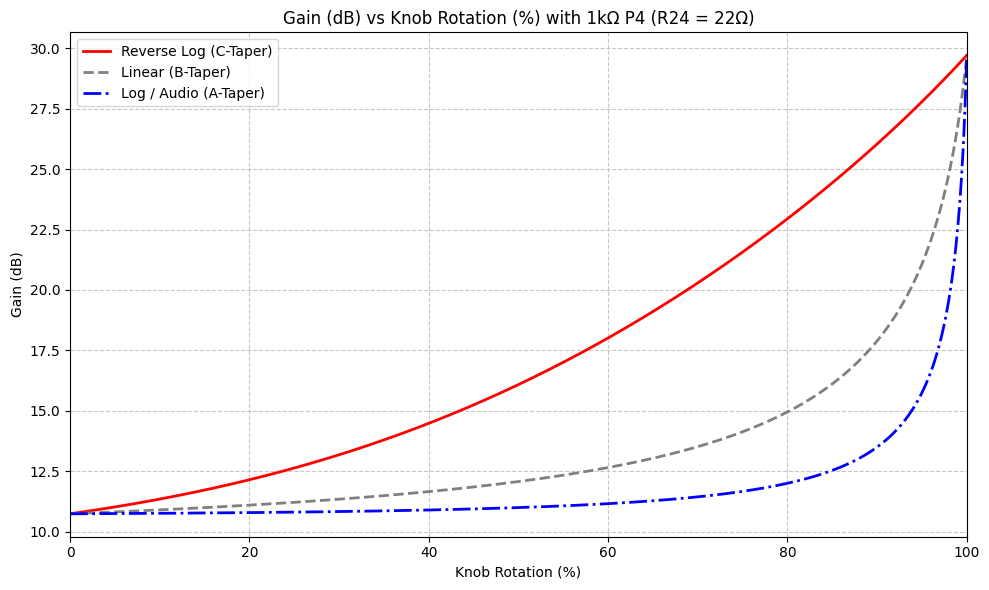

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# --- Schematic Values ---
R7 = 610
R8 = 330
R24 = 22
P4_max = 1000

# --- Taper Functions (0 to 1 normalized) ---
def taper_B(x):
    return x # Linear (B-Taper)

def taper_A(x):
    # Log / Audio (A-Taper): Approximating a standard 15% resistance at 50% rotation
    a = 31.6 
    return (a**x - 1) / (a - 1)

def taper_C(x):
    # Reverse Log (C-Taper): The inverse curve of the A-Taper
    return 1 - taper_A(1 - x)

# --- Calculations ---
# Array of knob rotation from 0 to 1 (0% to 100%)
rot = np.linspace(0, 1, 500)

# Pot is wired so 0% rotation = maximum resistance (lowest gain)
P4_val_B = P4_max * (1 - taper_B(rot))
P4_val_A = P4_max * (1 - taper_A(rot))
P4_val_C = P4_max * (1 - taper_C(rot))

def calc_gain_db(P4_val):
    # Calculate parallel resistance: R8 || (R24 + P4)
    R_parallel = (R8 * (R24 + P4_val)) / (R8 + R24 + P4_val)
    # Calculate linear gain then convert to dB
    gain_linear = 1 + (R7 / R_parallel)
    return 20 * np.log10(gain_linear)

gain_db_B = calc_gain_db(P4_val_B)
gain_db_A = calc_gain_db(P4_val_A)
gain_db_C = calc_gain_db(P4_val_C)

# --- Plotting ---
plt.figure(figsize=(10, 6))

plt.plot(rot * 100, gain_db_C, color='red', linewidth=2, label='Reverse Log (C-Taper)')
plt.plot(rot * 100, gain_db_B, color='gray', linestyle='--', linewidth=2, label='Linear (B-Taper)')
plt.plot(rot * 100, gain_db_A, color='blue', linestyle='-.', linewidth=2, label='Log / Audio (A-Taper)')

plt.title('Gain (dB) vs Knob Rotation (%) with 1kΩ P4 (R24 = 22Ω)')
plt.xlabel('Knob Rotation (%)')
plt.ylabel('Gain (dB)')
plt.xlim(0, 100)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()